In [127]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [128]:
df=pd.read_csv(r"C:\Users\burha\OneDrive\practice_datasets\jobanalyserproject\cleaned_job_naukari.csv",keep_default_na=False)

In [129]:
df.head()

,industry,jobtitle,Min_Exp_years,Max_Exp_years,job_description,skills
0,IT-Software / Software Services,Pl/sql Developer - SQL,4,8,as a developer in providing application design...,application programming
1,Banking / Financial Services / Broking,Manager/ad/partner - Indirect Tax - CA,11,15,Involved with all stages of indirect taxation ...,accounts
2,IT-Software / Software Services,JAVA Technical Lead (6-8 yrs) -,6,8,Strong background in Java J EE Data Structures...,application programming
3,IT-Software / Software Services,WALK IN - As400 Developer - Pfsweb Global Serv...,2,5,We are currently hiring candidates willing to ...,application programming
4,IT-Software / Software Services,PHP Developer,1,3,experience strong knowledge in PHP web applica...,application programming


In [130]:
df.shape

(16484, 6)

In [131]:
df.isna().sum()

industry           0
jobtitle           0
Min_Exp_years      0
Max_Exp_years      0
job_description    0
skills             0
dtype: int64

In [132]:
df['combined_data'] = (df['jobtitle'] + " " + df['job_description'])

In [133]:
df

,industry,jobtitle,Min_Exp_years,Max_Exp_years,job_description,skills,combined_data
0,IT-Software / Software Services,Pl/sql Developer - SQL,4,8,as a developer in providing application design...,application programming,Pl/sql Developer - SQL as a developer in provi...
1,Banking / Financial Services / Broking,Manager/ad/partner - Indirect Tax - CA,11,15,Involved with all stages of indirect taxation ...,accounts,Manager/ad/partner - Indirect Tax - CA Involve...
2,IT-Software / Software Services,JAVA Technical Lead (6-8 yrs) -,6,8,Strong background in Java J EE Data Structures...,application programming,JAVA Technical Lead (6-8 yrs) - Strong backgro...
3,IT-Software / Software Services,WALK IN - As400 Developer - Pfsweb Global Serv...,2,5,We are currently hiring candidates willing to ...,application programming,WALK IN - As400 Developer - Pfsweb Global Serv...
4,IT-Software / Software Services,PHP Developer,1,3,experience strong knowledge in PHP web applica...,application programming,PHP Developer experience strong knowledge in P...
...,...,...,...,...,...,...,...
16479,Banking / Financial Services / Broking,Quality Assurance - VP with Morgan Stanley Ban...,9,13,Morgan Stanley We would like to consider you f...,qa testing,Quality Assurance - VP with Morgan Stanley Ban...
16480,IT-Software / Software Services,Java Backend Developers for a Product Company,3,5,Looking for candidates with strong programming...,application programming,Java Backend Developers for a Product Company ...
16481,Internet / Ecommerce,Full Stack Development Engineer,2,4,Work with tech lead to architect and develop a...,application programming,Full Stack Development Engineer Work with tech...
16482,IT-Software / Software Services,Sr UI Developer/ Technical Lead - Html/ CSS/ J...,7,12,We are looking for a Senior UI Developers and ...,application programming,Sr UI Developer/ Technical Lead - Html/ CSS/ J...


In [134]:
df.drop(columns=['job_description','jobtitle'],inplace=True,axis=1)

we ignored skills rn because if tomorrow a resume doesn’t contain the exact word “accounts”,
but describes taxation work, your model may fail.
Because it didn’t learn deeper patterns.
It learned surface triggers

In [135]:
##Divinding our X and y features
X= df['combined_data']
y= df['industry']

In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size=0.2, random_state=42)

In [137]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=8500, lowercase=True, stop_words='english', ngram_range=(1,2), min_df=5)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [138]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)


In [139]:
from sklearn.metrics import accuracy_score, classification_report

cr=classification_report(y_pred,y_test)
print(cr)

                                               precision    recall  f1-score   support

Automobile / Auto Anciliary / Auto Components       0.96      1.00      0.98        95
                     BPO / Call Centre / ITES       0.91      0.98      0.94       243
       Banking / Financial Services / Broking       0.92      0.97      0.95       226
 Construction / Engineering / Cement / Metals       0.93      1.00      0.96        63
              Education / Teaching / Training       0.94      1.00      0.97       235
              IT-Software / Software Services       1.00      0.95      0.97      1922
                         Internet / Ecommerce       0.97      1.00      0.98       142
             Medical / Healthcare / Hospitals       0.86      0.97      0.91        75
         Pharma / Biotech / Clinical Research       0.92      1.00      0.96        94
                       Recruitment / Staffing       0.88      0.99      0.93       202

                                     accu

In [140]:
X_all_vec = tfidf.transform(df['combined_data'])

In [108]:
X_all_vec

<16484x8500 sparse matrix of type '<class 'numpy.float64'>'
	with 2384092 stored elements in Compressed Sparse Row format>

In [141]:
from sklearn.cluster import KMeans

kmeans = KMeans()
kmeans.fit(X_all_vec)

KMeans()

In [142]:
## Elbow method To select K Value
wcss=[]
for k in range(1,21):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_all_vec)
    wcss.append(kmeans.inertia_)

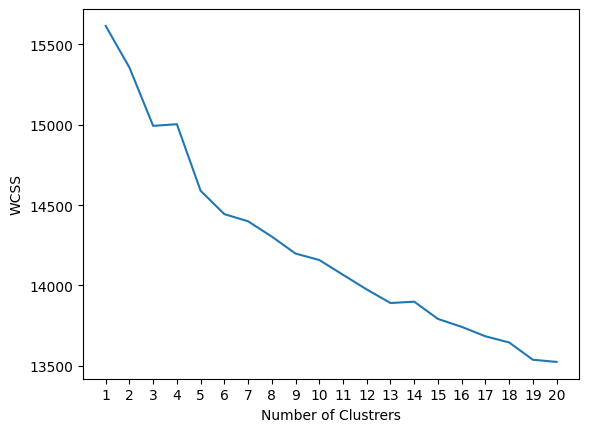

In [143]:
## plot elbow curve
plt.plot(range(1,21),wcss)
plt.xticks(range(1,21))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [144]:
wcss

[15615.446159092808,
 15356.29849731012,
 14993.439868410458,
 15003.753468959663,
 14589.322082514786,
 14443.949259600276,
 14399.428219922109,
 14304.00748981835,
 14198.569764519225,
 14158.437027012153,
 14066.431243483505,
 13975.143938210964,
 13890.701531623647,
 13899.143373490282,
 13791.791060870648,
 13742.405496517058,
 13683.626311089592,
 13645.26683438696,
 13537.61238913465,
 13524.134359151087]

In [113]:
from kneed import KneeLocator

In [114]:
kl=KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")

In [115]:
kl.elbow

8

In [117]:
## silhoutte score
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,12):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_all_vec)
    score=silhouette_score(X_all_vec,kmeans.labels_)
    silhouette_coefficients.append(score)

In [118]:
silhouette_coefficients


[0.033608818285273616,
 0.020962054972581915,
 0.034650089354043734,
 0.023480781680642143,
 0.02111745807442251,
 0.033557348784029425,
 0.04353405186181024,
 0.03671750179588242,
 0.041058115806078536,
 -0.002342664742483753]

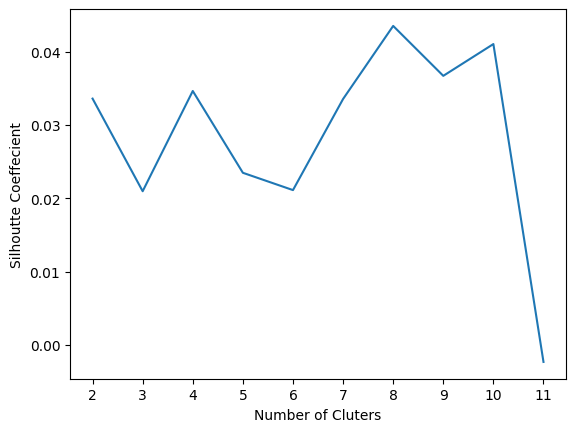

In [120]:
## plotting silhouette score
plt.plot(range(2,12),silhouette_coefficients)
plt.xticks(range(2,12))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()

In [148]:
### we taking k = 10

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X_all_vec)

KMeans(n_clusters=10, random_state=42)

In [146]:
kmeans.labels_

array([ 4,  9,  5, ..., 10, 10,  4])

In [151]:
df['cluster'] = kmeans.labels_

In [152]:
# Filter for Cluster 1 and get the average experience
cluster_1_stats = df[df['cluster'] == 5][['Min_Exp_years', 'Max_Exp_years']].mean()
print("Cluster 5 Average Experience Profile:")
print(cluster_1_stats)

Cluster 5 Average Experience Profile:
Min_Exp_years    1.172249
Max_Exp_years    4.536842
dtype: float64


In [153]:
df[df['cluster']==6]
print(df[df['cluster'] == 6]['skills'].value_counts().head(10))
# Filter for Cluster 1 and get the average experience
cluster_1_stats = df[df['cluster'] == 6][['Min_Exp_years', 'Max_Exp_years']].mean()
print("Cluster 6 Average Experience Profile:")
print(cluster_1_stats)

skills
application programming    622
teaching                   441
production                 384
medical                    372
network administration     201
engineering design         189
erp                        185
site engineering           128
ites                       107
dba                         97
Name: count, dtype: int64
Cluster 6 Average Experience Profile:
Min_Exp_years    3.447329
Max_Exp_years    6.998806
dtype: float64


In [159]:
print(df[df['cluster'] ==9]['skills'].value_counts().head(10))
# Filter for Cluster 1 and get the average experience
cluster_1_stats = df[df['cluster'] == 9][['Min_Exp_years', 'Max_Exp_years']].mean()
print("Cluster 9 Average Experience Profile:")
print(cluster_1_stats)


skills
sales                      1597
financial services           33
marketing                    13
ites                          8
application programming       4
hotels                        2
hr                            2
accounts                      2
medical                       2
teaching                      2
Name: count, dtype: int64
Cluster 9 Average Experience Profile:
Min_Exp_years    3.174147
Max_Exp_years    6.680431
dtype: float64


In [155]:
print(df[df['cluster'] == 8]['skills'].value_counts().head(10))
# Filter for Cluster 1 and get the average experience
cluster_1_stats = df[df['cluster'] == 8][['Min_Exp_years', 'Max_Exp_years']].mean()
print("Cluster 8 Average Experience Profile:")
print(cluster_1_stats)


skills
application programming            793
marketing                          498
financial services                 295
ites                               256
other                              158
journalism                         147
analytics business intelligence    120
sales                              106
ecommerce                           95
network administration              93
Name: count, dtype: int64
Cluster 8 Average Experience Profile:
Min_Exp_years    4.535155
Max_Exp_years    8.052502
dtype: float64


In [156]:
print(df[df['cluster'] == 7]['skills'].value_counts().head(10))
# Filter for Cluster 1 and get the average experience
cluster_1_stats = df[df['cluster'] == 7][['Min_Exp_years', 'Max_Exp_years']].mean()
print("Cluster 7 Average Experience Profile:")
print(cluster_1_stats)


skills
application programming      591
other                         13
system programming            11
dba                            9
ecommerce                      7
client server programming      4
erp                            2
mobile                         2
network administration         1
architecture                   1
Name: count, dtype: int64
Cluster 7 Average Experience Profile:
Min_Exp_years    3.692068
Max_Exp_years    7.136858
dtype: float64


In [157]:
print(df[df['cluster'] == 5]['skills'].value_counts().head(10))

skills
ites                       1035
application programming       4
travel                        2
journalism                    1
sales                         1
marketing                     1
hr                            1
Name: count, dtype: int64


In [158]:
cluster_names = {
    0: 'Strategic Sales & Business Development',
    1: 'Mid-Senior Software Engineering',
    2: 'Associate Operations & Service Delivery',
    3: 'Human Resources & Talent Management',
    4: 'Clinical Research & Industrial Production',
    5: 'Full-Stack & Mobile Product Development',
    6: 'Academic Instruction & Training',
    7: 'University Faculty & Advanced Research',
    8: 'Enterprise ERP Consulting & Systems',
    9: 'Corporate Finance, Marketing & Business Ops'
}

In [169]:
"""
cluster_names = {
0: "QA / Testing",
1: "System Programming",
2: "Healthcare",
3: "Recruitment",
4: "DevOps",
5: "Backend Engineering",
6: "Frontend",
7: "Data Science",
8: "Accounting",
9: "Taxation"
}
""" 

'\ncluster_names = {\n0: "QA / Testing",\n1: "System Programming",\n2: "Healthcare",\n3: "Recruitment",\n4: "DevOps",\n5: "Backend Engineering",\n6: "Frontend",\n7: "Data Science",\n8: "Accounting",\n9: "Taxation"\n}\n'

In [ ]:
df['Cluster_Name'] = df['cluster'].map(cluster_names)

In [160]:
df

,industry,Min_Exp_years,Max_Exp_years,skills,combined_data,cluster
0,IT-Software / Software Services,4,8,application programming,Pl/sql Developer - SQL as a developer in provi...,1
1,Banking / Financial Services / Broking,11,15,accounts,Manager/ad/partner - Indirect Tax - CA Involve...,4
2,IT-Software / Software Services,6,8,application programming,JAVA Technical Lead (6-8 yrs) - Strong backgro...,1
3,IT-Software / Software Services,2,5,application programming,WALK IN - As400 Developer - Pfsweb Global Serv...,1
4,IT-Software / Software Services,1,3,application programming,PHP Developer experience strong knowledge in P...,1
...,...,...,...,...,...,...
16479,Banking / Financial Services / Broking,9,13,qa testing,Quality Assurance - VP with Morgan Stanley Ban...,3
16480,IT-Software / Software Services,3,5,application programming,Java Backend Developers for a Product Company ...,1
16481,Internet / Ecommerce,2,4,application programming,Full Stack Development Engineer Work with tech...,1
16482,IT-Software / Software Services,7,12,application programming,Sr UI Developer/ Technical Lead - Html/ CSS/ J...,1


In [161]:
from sklearn.preprocessing import LabelEncoder


le_industry = LabelEncoder()
le_skills = LabelEncoder()

# Create new numerical columns
df['industry_n'] = le_industry.fit_transform(df['industry'])
df['skills_n'] = le_skills.fit_transform(df['skills'])

print(df[['industry', 'industry_n', 'skills', 'skills_n']].head())

                                 industry  industry_n  \
0         IT-Software / Software Services           5   
1  Banking / Financial Services / Broking           2   
2         IT-Software / Software Services           5   
3         IT-Software / Software Services           5   
4         IT-Software / Software Services           5   

                    skills  skills_n  
0  application programming         2  
1                 accounts         0  
2  application programming         2  
3  application programming         2  
4  application programming         2  


In [163]:
df['industry_n'].unique()

array([5, 2, 9, 6, 1, 8, 0, 7, 4, 3])

In [164]:
# X = The features the model learns from
X = df[['Min_Exp_years', 'Max_Exp_years', 'industry_n', 'skills_n']]

# y = The target (the cluster numbers we want to predict)
y = df['cluster']

In [165]:
from sklearn.model_selection import train_test_split

# We'll save 20% of the data to test the model later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 13187
Testing set size: 3297


In [174]:
from sklearn.tree import DecisionTreeClassifier


clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [175]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 74.83%


In [176]:
train_accuracy = accuracy_score(y_train, clf.predict(X_train))
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Training Accuracy: 77.28%
Test Accuracy: 74.83%


In [181]:
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.utils import simple_preprocess
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

custom_stopwords = stop_words | {
    'bangalore', 'hyderabad', 'mumbai', 'delhi', 'chennai',
    'location', 'current', 'job', 'years', 'experience',
    'salary', 'apply', 'candidate', 'please', 'looking',
    'pune', 'kolkata', 'gurgaon', 'noida', 'company',
    'profile', 'view', 'contact', 'details', 'download',
    'send', 'like', 'role', 'skills', 'required', 'good'
}

def tokenize_for_lda(text):
    if not isinstance(text, str):
        return []
    return [w for w in simple_preprocess(text) if w not in custom_stopwords and len(w) > 2]

df['tokens'] = df['combined_data'].apply(tokenize_for_lda)

dictionary = corpora.Dictionary(df['tokens'])
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=10,
    alpha='auto'
)

print("LDA training done. Topics found:")
for idx, topic in lda_model.print_topics(num_topics=10, num_words=6):
    print(f"  Topic {idx}: {topic}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\burha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


LDA training done. Topics found:
  Topic 0: 0.032*"bpo" + 0.027*"medical" + 0.022*"customer" + 0.021*"ites" + 0.020*"call" + 0.019*"voice"
  Topic 1: 0.025*"security" + 0.017*"network" + 0.016*"support" + 0.014*"system" + 0.012*"admin" + 0.012*"administration"
  Topic 2: 0.028*"data" + 0.023*"business" + 0.021*"financial" + 0.019*"management" + 0.018*"sap" + 0.016*"banking"
  Topic 3: 0.038*"teaching" + 0.037*"pay" + 0.030*"training" + 0.022*"tax" + 0.022*"accounts" + 0.020*"academic"
  Topic 4: 0.023*"content" + 0.022*"engineering" + 0.021*"design" + 0.014*"production" + 0.013*"maintenance" + 0.013*"manufacturing"
  Topic 5: 0.018*"management" + 0.015*"team" + 0.011*"work" + 0.010*"recruitment" + 0.009*"ability" + 0.009*"project"
  Topic 6: 0.070*"sales" + 0.038*"business" + 0.034*"marketing" + 0.028*"development" + 0.022*"manager" + 0.016*"retail"
  Topic 7: 0.020*"testing" + 0.019*"design" + 0.018*"technical" + 0.018*"development" + 0.015*"test" + 0.012*"team"
  Topic 8: 0.036*"prog

In [182]:
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

df['lda_topic'] = [get_dominant_topic(bow) for bow in corpus]
print(df[['combined_data', 'cluster', 'lda_topic']].head(10))

                                       combined_data  cluster  lda_topic
0  Pl/sql Developer - SQL as a developer in provi...        1          7
1  Manager/ad/partner - Indirect Tax - CA Involve...        4          5
2  JAVA Technical Lead (6-8 yrs) - Strong backgro...        1          9
3  WALK IN - As400 Developer - Pfsweb Global Serv...        1          8
4  PHP Developer experience strong knowledge in P...        1          9
5  German Translator Overall Purpose of Job and R...        5          5
6  Opening for Android Developer-bangalore-4-8 yr...        1          8
7  Full Stack Web Application (php) Developer We ...        1          9
8  Looking for an Application Engineer-fpga HDL V...        1          4
9  Revenue Assurance Responsibilities Manage dayt...        4          1


In [186]:
def predict_job(text, skills_input, industry_input, min_exp, max_exp):
    """
    Given raw text + metadata, return industry prediction + cluster + LDA topics.
    This is the function the FastAPI backend will call.
    """
    # 1. Vectorize text
    vec = tfidf.transform([text])

    # 2. Predict industry
    predicted_industry = model.predict(vec)[0]
    industry_probs = model.predict_proba(vec)[0]
    industry_confidence = round(max(industry_probs) * 100, 1)

    # 3. Encode inputs for cluster prediction
    try:
        ind_n = le_industry.transform([industry_input])[0]
    except:
        ind_n = le_industry.transform([predicted_industry])[0]

    try:
        sk_n = le_skills.transform([skills_input])[0]
    except:
       sk_n = le_skills.transform([df['skills'].mode()[0]])[0]  # fallback to most common

    # 4. Predict cluster
    cluster_id = clf.predict(
    pd.DataFrame([[min_exp, max_exp, ind_n, sk_n]],columns=['Min_Exp_years', 'Max_Exp_years', 'industry_n', 'skills_n']))[0]
    cluster_label = cluster_names[cluster_id]

    # 5. Get LDA topics
    bow = dictionary.doc2bow(tokenize_for_lda(text))
    lda_topics = lda_model.get_document_topics(bow)
    top_topics = sorted(lda_topics, key=lambda x: x[1], reverse=True)[:3]

    return {
        'predicted_industry': predicted_industry,
        'industry_confidence': industry_confidence,
        'cluster_id': int(cluster_id),
        'cluster_name': cluster_label,
        'top_lda_topics': [(int(t[0]), round(float(t[1]), 3)) for t in top_topics]
    }

# Test it
result = predict_job(
    text="Looking for a Python developer with Django and REST API experience",
    skills_input="application programming",
    industry_input="IT-Software / Software Services",
    min_exp=2,
    max_exp=5
)
print(result)

{'predicted_industry': 'IT-Software / Software Services', 'industry_confidence': 58.9, 'cluster_id': 1, 'cluster_name': 'Mid-Senior Software Engineering', 'top_lda_topics': [(9, 0.852), (5, 0.027), (7, 0.02)]}


In [187]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(tfidf,       'models/tfidf_vectorizer.pkl')
joblib.dump(model,       'models/industry_model.pkl')
joblib.dump(kmeans,      'models/kmeans_model.pkl')
joblib.dump(clf,         'models/cluster_clf.pkl')
joblib.dump(le_industry, 'models/le_industry.pkl')
joblib.dump(le_skills,   'models/le_skills.pkl')
joblib.dump(lda_model,   'models/lda_model.pkl')
joblib.dump(dictionary,  'models/lda_dictionary.pkl')
joblib.dump(cluster_names, 'models/cluster_names.pkl')

print("Saved files:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"  {f:35s} {size:.1f} KB")

Saved files:
  cluster_clf.pkl                     116.8 KB
  cluster_names.pkl                   0.4 KB
  industry_model.pkl                  665.5 KB
  kmeans_model.pkl                    729.2 KB
  lda_dictionary.pkl                  341.1 KB
  lda_model.pkl                       1299.1 KB
  le_industry.pkl                     0.9 KB
  le_skills.pkl                       1.3 KB
  tfidf_vectorizer.pkl                311.4 KB
